In [211]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [212]:
df=pd.read_csv('heart.csv')

In [213]:
df.shape

(918, 12)

In [214]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [215]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


EDA

In [216]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [217]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [218]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [219]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

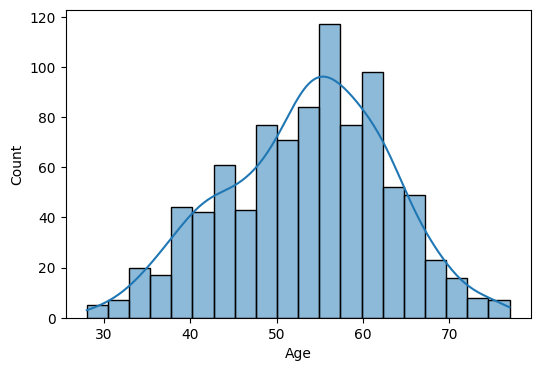

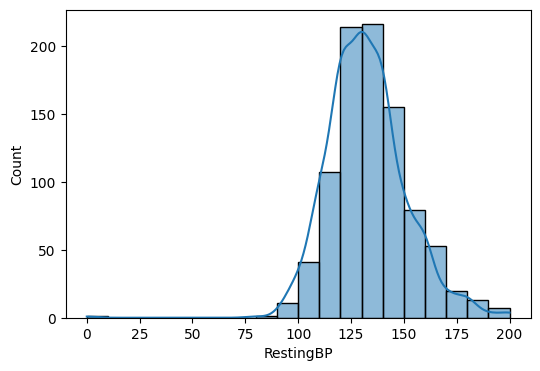

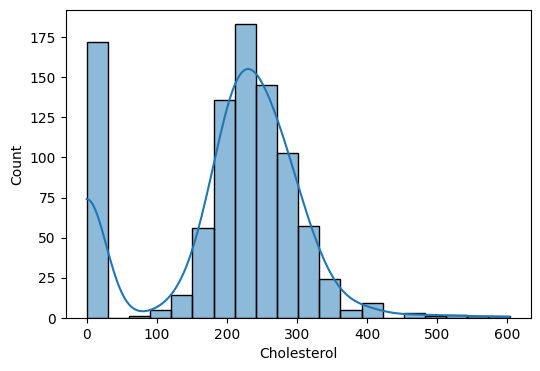

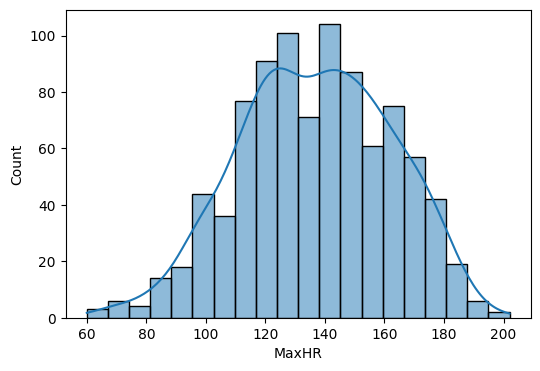

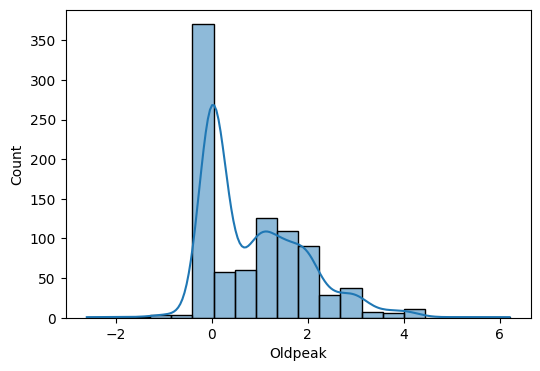

In [220]:
numeric_columns=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

## OR WE CAN PLOT ALL GRAPHS TOGETHER USING FUNCTION

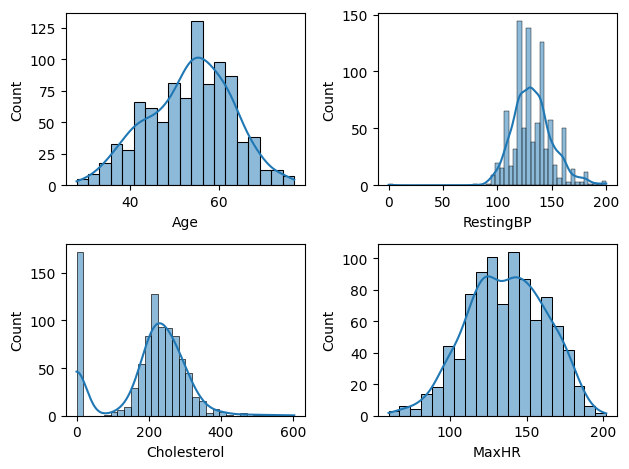

In [221]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [222]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [223]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
174      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64

## here we notice one thing in restingbp here one is 0 means one of the person has resting bp 0 but it is impossible so it is the error also we find one more thing almost 172 has zero cholestrol which is impossible so this is one more error

In [224]:
## now fill the value of cholesterol 0 
ch_mean=df.loc[df['Cholesterol']!=0 ,'Cholesterol'].mean()

In [225]:
ch_mean

np.float64(244.6353887399464)

In [226]:
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol']=df['Cholesterol'].round(2)

In [227]:
rest_bp_mean=df.loc[df['RestingBP']!=0 ,'RestingBP'].mean()
df['RestingBP']=df['RestingBP'].replace(0,rest_bp_mean).round(2)
rest_bp_mean


np.float64(132.54089422028352)

In [228]:
df['Cholesterol'].value_counts()

Cholesterol
244.64    172
254.00     11
223.00     10
220.00     10
211.00      9
         ... 
353.00      1
278.00      1
157.00      1
176.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [229]:
df['RestingBP'].value_counts()

RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
        ... 
174.0      1
117.0      1
192.0      1
129.0      1
164.0      1
Name: count, Length: 67, dtype: int64

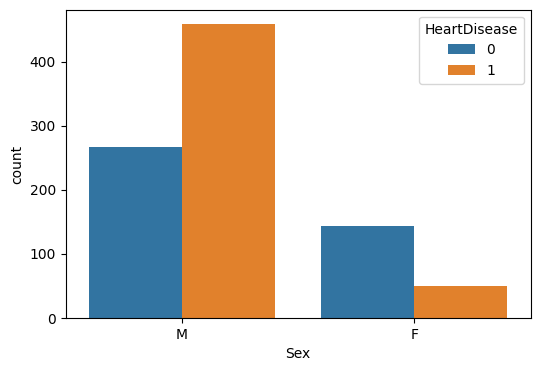

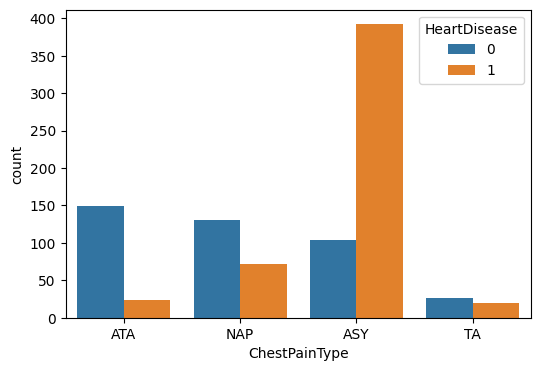

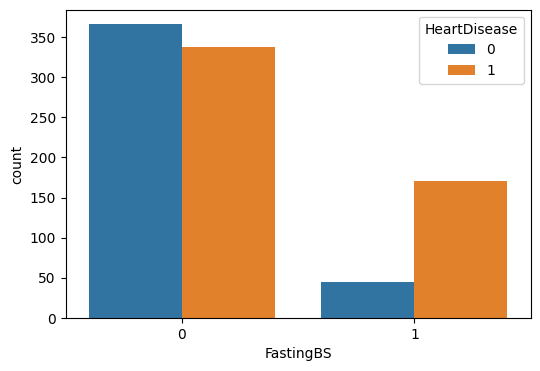

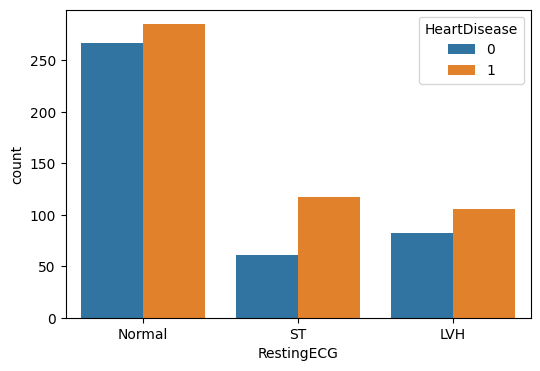

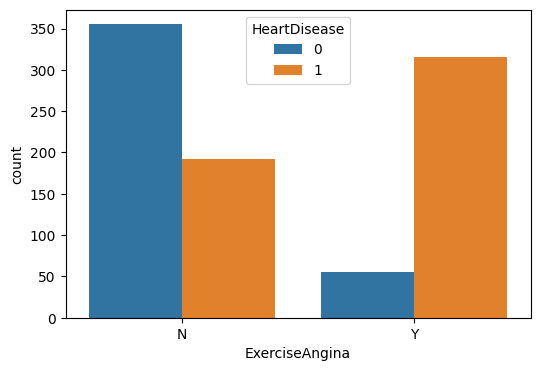

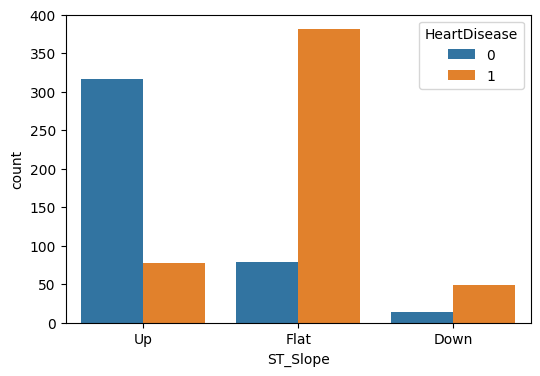

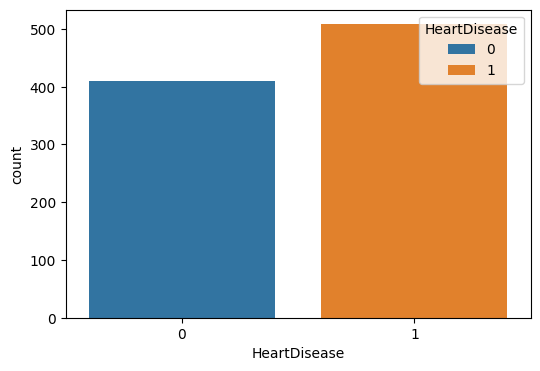

In [230]:
categorical_columns=['Sex','ChestPainType','FastingBS','RestingECG','ExerciseAngina','ST_Slope','HeartDisease']
for cat in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[cat],hue=df['HeartDisease'])

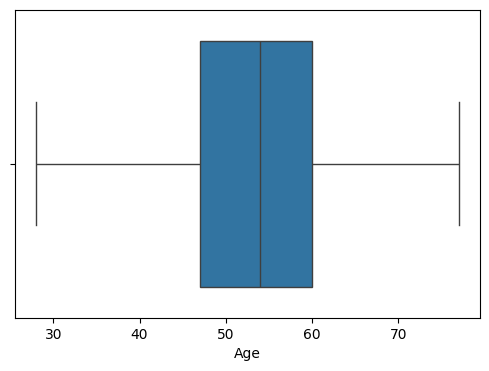

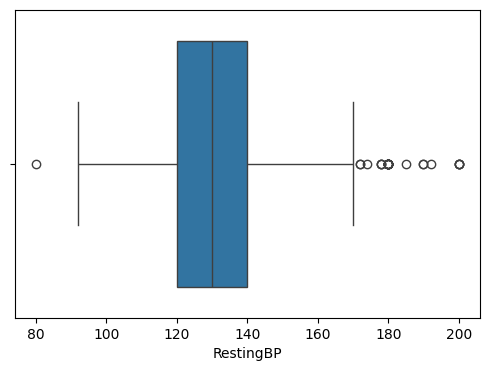

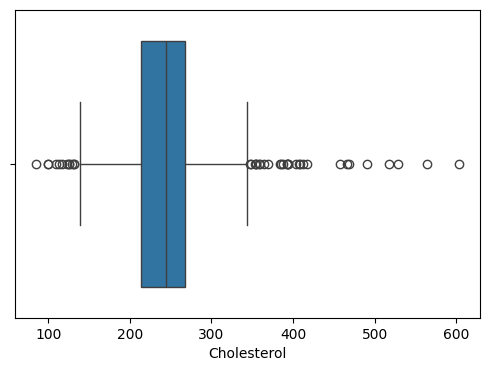

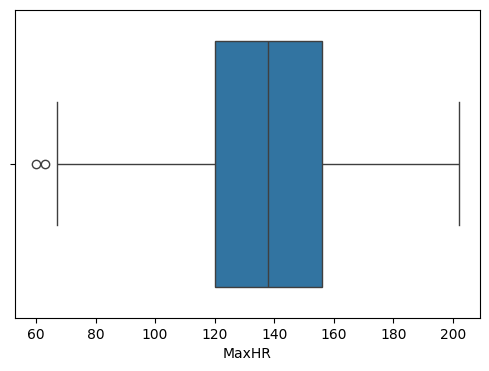

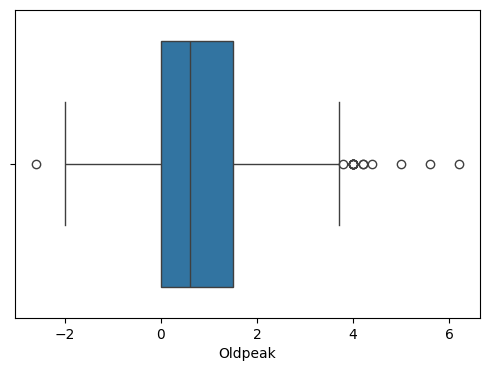

In [231]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

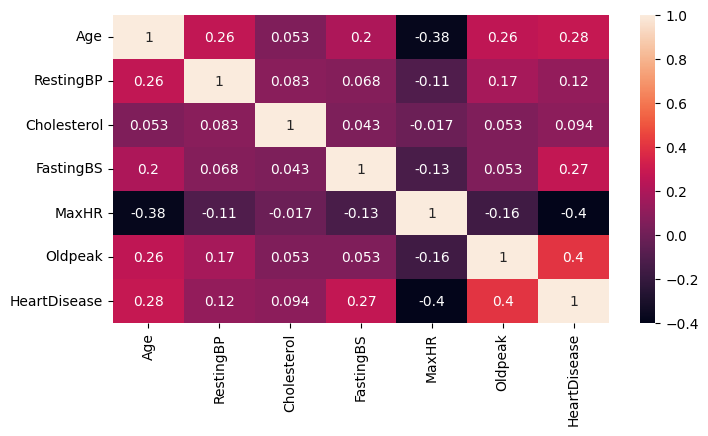

In [232]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

Cleaning and Preprocessing

In [233]:
df_cleaned=df.copy()

In [234]:
df_cleaned.shape

(918, 12)

In [235]:
df_cleaned.duplicated().sum()

np.int64(0)

In [236]:
df_cleaned.drop_duplicates(inplace=True)

In [237]:
df_cleaned.shape

(918, 12)

In [238]:
df_cleaned.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP         float64
Cholesterol       float64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [239]:
df_cleaned['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [240]:
df_cleaned['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [241]:
df_cleaned['Age'].value_counts()

Age
54    51
58    42
55    41
56    38
57    38
52    36
51    35
59    35
62    35
53    33
60    32
48    31
61    31
63    30
50    25
43    24
41    24
46    24
64    22
49    21
65    21
44    19
47    19
45    18
42    18
38    16
39    15
67    15
40    13
66    13
69    13
37    11
35    11
68    10
34     7
74     7
70     7
36     6
32     5
71     5
72     4
29     3
75     3
31     2
33     2
77     2
76     2
28     1
30     1
73     1
Name: count, dtype: int64

In [242]:
df_cleaned['MaxHR'].value_counts()

MaxHR
150    43
140    41
120    36
130    33
160    25
       ..
192     1
195     1
194     1
187     1
202     1
Name: count, Length: 119, dtype: int64

In [243]:
for column in df_cleaned.columns:
    print(f"\n{'='*40}")
    print(f"Column: {column}")
    print(df_cleaned[column].value_counts().head())


Column: Age
Age
54    51
58    42
55    41
56    38
57    38
Name: count, dtype: int64

Column: Sex
Sex
M    725
F    193
Name: count, dtype: int64

Column: ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

Column: RestingBP
RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
Name: count, dtype: int64

Column: Cholesterol
Cholesterol
244.64    172
254.00     11
223.00     10
220.00     10
211.00      9
Name: count, dtype: int64

Column: FastingBS
FastingBS
0    704
1    214
Name: count, dtype: int64

Column: RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

Column: MaxHR
MaxHR
150    43
140    41
120    36
130    33
160    25
Name: count, dtype: int64

Column: ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

Column: Oldpeak
Oldpeak
0.0    368
1.0     86
2.0     76
1.5     53
3.0     28
Name: count, dtype: int64

Column: ST_Slope
ST_Slope
Flat    46

In [244]:
df_cleaned=pd.get_dummies(df_cleaned)

In [245]:
df_cleaned

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,False,True,False,...,False,True,False,True,False,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,False,True,True,...,False,False,False,True,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,False,True,True,...,False,False,False,True,False,False,True,False,True,False
916,57,130.0,236.0,0,174,0.0,1,True,False,False,...,False,False,True,False,False,True,False,False,True,False


In [246]:
df_cleaned=df_cleaned.astype(int)

In [247]:
df_cleaned.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [248]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


In [249]:
X=df_cleaned.drop('HeartDisease',axis=1)
y=df_cleaned['HeartDisease']

In [250]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [251]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [252]:
models={
    "Logistic Regression": LogisticRegression(),
    "KNN" : KNeighborsClassifier(n_neighbors=5),
    "Naive Byeas" : GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM(RBF kernel)" : SVC(kernel='rbf')
}

In [253]:
result=[]

In [254]:
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_test_pred=model.predict(X_test_scaled)
    y_train_pred=model.predict(X_train_scaled)
    acc_test=accuracy_score(y_test,y_test_pred)
    acc_train=accuracy_score(y_train,y_train_pred)
    matrix=confusion_matrix(y_test,y_test_pred)
    report=classification_report(y_test,y_test_pred)
    result.append({
        'model':name,
        'Accuracy_test': acc_test,
        'Accuracy_train': acc_train,
        'Confusion_matrix': matrix,
        'Classification_report': report
    })

In [255]:
result

[{'model': 'Logistic Regression',
  'Accuracy_test': 0.875,
  'Accuracy_train': 0.8664850136239782,
  'Confusion_matrix': array([[68,  9],
         [14, 93]]),
  'Classification_report': '              precision    recall  f1-score   support\n\n           0       0.83      0.88      0.86        77\n           1       0.91      0.87      0.89       107\n\n    accuracy                           0.88       184\n   macro avg       0.87      0.88      0.87       184\nweighted avg       0.88      0.88      0.88       184\n'},
 {'model': 'KNN',
  'Accuracy_test': 0.8532608695652174,
  'Accuracy_train': 0.8841961852861036,
  'Confusion_matrix': array([[66, 11],
         [16, 91]]),
  'Classification_report': '              precision    recall  f1-score   support\n\n           0       0.80      0.86      0.83        77\n           1       0.89      0.85      0.87       107\n\n    accuracy                           0.85       184\n   macro avg       0.85      0.85      0.85       184\nweighted a

In [256]:
import joblib
joblib.dump(models['Logistic Regression'], 'LR_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']

In [257]:
import sklearn
print(sklearn.__version__)

1.8.0


In [258]:
import numpy
print(numpy.__version__)

2.4.2


In [259]:
import pandas
print(pandas.__version__)

3.0.0


In [260]:
import joblib
print(joblib.__version__)

1.5.3
